In [1]:
import os
import geopandas as gpd
import requests
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
urls = {
    "Demografi": "https://geoserver.mapid.io/layers_new/get_layer?api_key=1fb8fddf1269435a8d65d77cdcc56c59&layer_id=68ac2bffb2fcc5561a2f6b7b&project_id=68ac2b896386ff356dced356&limit=10000",
    "Tutupan Lahan": "https://geoserver.mapid.io/layers_new/get_layer?api_key=1fb8fddf1269435a8d65d77cdcc56c59&layer_id=68ac2be3b2fcc5561a2f6b34&project_id=68ac2b896386ff356dced356&limit=10000",
    "Risiko Banjir": "https://geoserver.mapid.io/layers_new/get_layer?api_key=1fb8fddf1269435a8d65d77cdcc56c59&layer_id=68ac2bbbb2fcc5561a2f68ad&project_id=68ac2b896386ff356dced356&limit=10000"
}


In [19]:
# Mengambil data dan skoring

def get_data(url, layer_name):
    response = requests.get(url)
    print(f"Status {layer_name}: {response.status_code}")  # debug

    if response.status_code == 200:
        geojson_data = response.json()
        print(f"Keys {layer_name}: {geojson_data.keys()}")  # debug

        gdf = gpd.GeoDataFrame.from_features(geojson_data['features'], crs="EPSG:4326")

        # Skoring
        if layer_name == "Demografi":
            if "KEPADATAN PENDUDUK" in gdf.columns:
                gdf["SKOR_DEMOGRAFI"] = pd.qcut(gdf["KEPADATAN PENDUDUK"], 3, labels=[1,2,3]).astype(int)

        elif layer_name == "Tutupan Lahan":
            if "KELAS" in gdf.columns:
                gdf["SKOR_TUTUPAN"] = gdf["KELAS"].astype(str).str.upper().map({
                    "HUTAN": 1, "SAWAH": 2, "TERBANGUN": 3
                }).fillna(0)

        elif layer_name == "Risiko Banjir":
            if "KELAS_RISIKO" in gdf.columns:
                gdf["SKOR_BANJIR"] = gdf["KELAS_RISIKO"].astype(str).str.upper().map({
                    "TINGGI": 3, "SEDANG": 2, "RENDAH": 1
                }).fillna(0)

        return gdf   # <---- ini penting
    else:
        print(f"Gagal ambil {layer_name}")
        return gpd.GeoDataFrame()


In [20]:
gdf_demografi = get_data(urls["Demografi"], "Demografi")
gdf_lahan = get_data(urls["Tutupan Lahan"], "Tutupan Lahan")
gdf_banjir = get_data(urls["Risiko Banjir"], "Risiko Banjir")

print("Demografi:", len(gdf_demografi), gdf_demografi.columns)
print("Tutupan Lahan:", len(gdf_lahan), gdf_lahan.columns)
print("Risiko Banjir:", len(gdf_banjir), gdf_banjir.columns)


Status Demografi: 200
Keys Demografi: dict_keys(['type', 'features'])
Status Tutupan Lahan: 200
Keys Tutupan Lahan: dict_keys(['type', 'features'])
Status Risiko Banjir: 200
Keys Risiko Banjir: dict_keys(['type', 'features'])
Demografi: 65 Index(['geometry', 'fid', 'ID_PROV', 'PROVINSI', 'ID_KABKOT', 'KABKOT',
       'ID_KEC', 'KECAMATAN', 'ID_DESA', 'DESA',
       ...
       'MENGURUS RUMAH TANGGA', 'PERDAGANGAN', 'PERAWAT', 'NELAYAN',
       'PELAJAR DAN MAHASISWA', 'GURU', 'WIRASWASTA', 'PENGACARA',
       'PEKERJAAN LAINNYA', 'SKOR_DEMOGRAFI'],
      dtype='object', length=104)
Tutupan Lahan: 17 Index(['geometry', 'CLASS', 'KELAS', 'SKOR_TUTUPAN'], dtype='object')
Risiko Banjir: 570 Index(['geometry', 'ID_PROV', 'PROVINSI', 'ID_KABKOT', 'KABKOT', 'ID_KEC',
       'KECAMATAN', 'ID_DESA', 'DESA', 'KELAS_RISIKO', 'SKOR_BANJIR'],
      dtype='object')


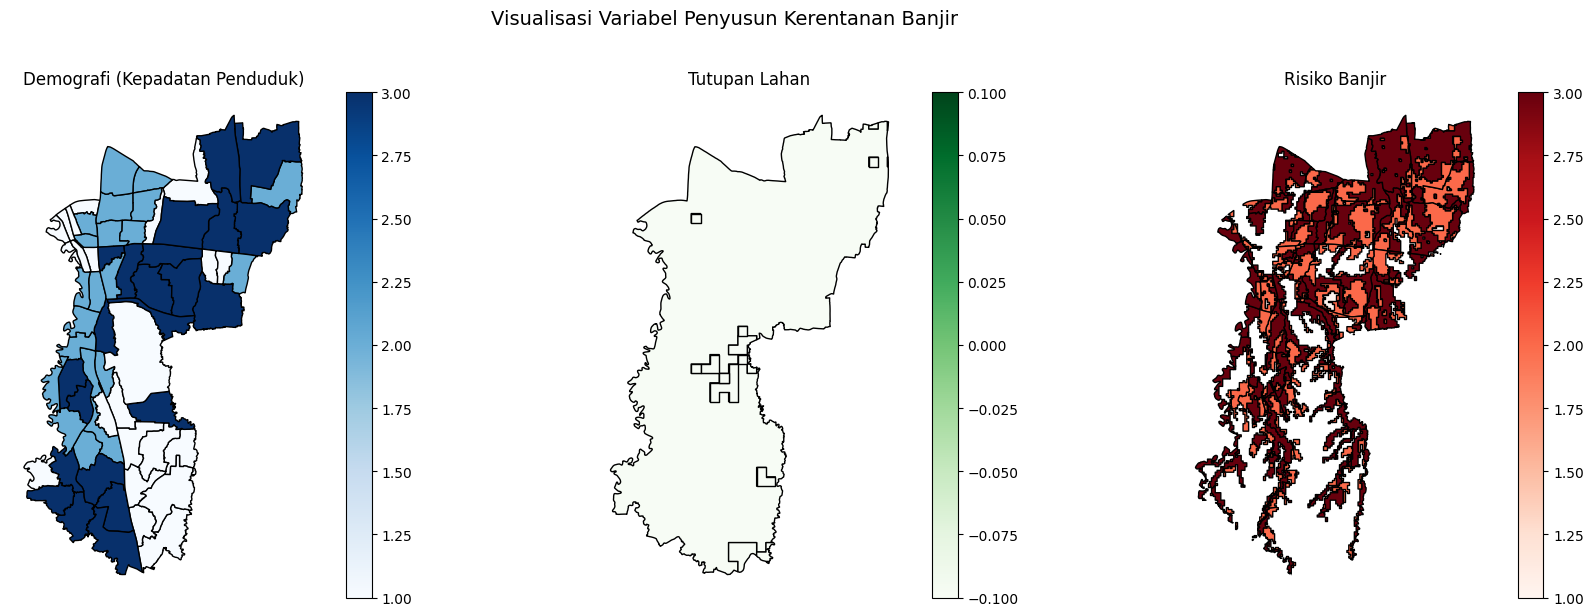

In [21]:
# Visualisasi Variabel

import matplotlib.pyplot as plt

# --- Visualisasi Variabel Penyusun ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Demografi
if "SKOR_DEMOGRAFI" in gdf_demografi.columns and not gdf_demografi.empty:
    gdf_demografi.plot(
        column="SKOR_DEMOGRAFI",
        cmap="Blues",
        legend=True,
        ax=axes[0],
        edgecolor="black"
    )
    axes[0].set_title("Demografi (Kepadatan Penduduk)")

# Tutupan Lahan
if "SKOR_TUTUPAN" in gdf_lahan.columns and not gdf_lahan.empty:
    gdf_lahan.plot(
        column="SKOR_TUTUPAN",
        cmap="Greens",
        legend=True,
        ax=axes[1],
        edgecolor="black"
    )
    axes[1].set_title("Tutupan Lahan")

# Risiko Banjir
if "SKOR_BANJIR" in gdf_banjir.columns and not gdf_banjir.empty:
    gdf_banjir.plot(
        column="SKOR_BANJIR",
        cmap="Reds",
        legend=True,
        ax=axes[2],
        edgecolor="black"
    )
    axes[2].set_title("Risiko Banjir")

# Hilangkan axis
for ax in axes:
    ax.axis("off")

plt.suptitle("Visualisasi Variabel Penyusun Kerentanan Banjir", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [22]:
import requests

url = "https://geoserver.mapid.io/layers_new/get_layer?api_key=1fb8fddf1269435a8d65d77cdcc56c59&layer_id=68ac2be3b2fcc5561a2f6b34&project_id=68ac2b896386ff356dced356"
response = requests.get(url)

print("Status:", response.status_code)
data = response.json()
print("Jumlah fitur:", len(data.get("features", [])))
print("Contoh properties:", data.get("features", [])[0]["properties"] if len(data.get("features", []))>0 else "Tidak ada fitur")


Status: 200
Jumlah fitur: 17
Contoh properties: {'CLASS': 'BUILT AREA', 'KELAS': 'WILAYAH TERBANGUN'}


In [23]:
import geopandas as gpd
import requests

def get_data_safe(url, layer_name):
    response = requests.get(url)
    if response.status_code == 200:
        geojson_data = response.json()
        features = [f for f in geojson_data["features"] if f.get("geometry") is not None]  # hanya yg ada geometry
        
        if len(features) == 0:
            print(f"[{layer_name}] Tidak ada geometry!")
            return gpd.GeoDataFrame()
        
        gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
        print(f"[{layer_name}] Jumlah fitur:", len(gdf))
        print(f"[{layer_name}] Kolom:", gdf.columns.tolist())
        return gdf
    else:
        print(f"[{layer_name}] Error API:", response.status_code)
        return gpd.GeoDataFrame()

# Coba ambil semua
gdf_demografi = get_data_safe(urls["Demografi"], "Demografi")
gdf_lahan = get_data_safe(urls["Tutupan Lahan"], "Tutupan Lahan")
gdf_banjir = get_data_safe(urls["Risiko Banjir"], "Risiko Banjir")


[Demografi] Jumlah fitur: 65
[Demografi] Kolom: ['geometry', 'fid', 'ID_PROV', 'PROVINSI', 'ID_KABKOT', 'KABKOT', 'ID_KEC', 'KECAMATAN', 'ID_DESA', 'DESA', 'JUMLAH PENDUDUK', 'JUMLAH KK', 'LUAS WILAYAH (KM²)', 'KEPADATAN PENDUDUK', 'PERPINDAHAN PENDUDUK', 'JUMLAH MENINGGAL', 'PERUBAHAN DATA', 'JUMLAH WAJIB KTP', 'JUMLAH REKAM WAJIB KTP', 'ISLAM', 'KRISTEN', 'KATHOLIK', 'HINDU', 'BUDDHA', 'KONGHUCU', 'KEPERCAYAAN TERHADAP TUHAN YME', 'LAKI-LAKI', 'PEREMPUAN', 'BELUM KAWIN', 'KAWIN', 'CERAI HIDUP', 'CERAI MATI', 'USIA 0-4', 'USIA 5-9', 'USIA 10-14', 'USIA 15-19', 'USIA 20-24', 'USIA 25-29', 'USIA 30-34', 'USIA 35-39', 'USIA 40-44', 'USIA 45-49', 'USIA 50-54', 'USIA 55-59', 'USIA 60-64', 'USIA 65-69', 'USIA 70-74', 'USIA 75 TAHUN KE ATAS', 'LAHIR TAHUN 2020', 'LAHIR SEBELUM TAHUN 2020', 'LAHIR TAHUN 2021', 'LAHIR SEBELUM TAHUN 2021', 'LAHIR TAHUN 2022', 'LAHIR SEBELUM TAHUN 2022', 'LAHIR TAHUN 2023', 'LAHIR SEBELUM TAHUN 2023', 'LAHIR TAHUN 2024', 'LAHIR SEBELUM 2024', 'PERTUMBUHAN PENDUD

In [24]:
# Skoring Demografi (pakai kepadatan penduduk)
gdf_demografi["SKOR_DEMOGRAFI"] = pd.cut(
    gdf_demografi["KEPADATAN PENDUDUK"],
    bins=[0, 1000, 5000, 100000],  # sesuaikan threshold
    labels=[1, 2, 3]
).astype(int)

# Skoring Tutupan Lahan
gdf_lahan["SKOR_TUTUPAN"] = gdf_lahan["KELAS"].str.upper().map({
    "TERBANGUN": 3, "NON TERBANGUN": 1
}).fillna(2)

# Skoring Risiko Banjir
gdf_banjir["SKOR_BANJIR"] = gdf_banjir["KELAS_RISIKO"].str.upper().map({
    "TINGGI": 3, "SEDANG": 2, "RENDAH": 1
}).fillna(0)

In [25]:
# Overlay dgn Intersect

gdf_overlay = gpd.overlay(gdf_demografi, gdf_lahan, how="intersection")
gdf_overlay = gpd.overlay(gdf_overlay, gdf_banjir, how="intersection")

# Hitung skor total
gdf_overlay["TOTAL_SKOR"] = (
    gdf_overlay["SKOR_DEMOGRAFI"] +
    gdf_overlay["SKOR_TUTUPAN"] +
    gdf_overlay["SKOR_BANJIR"]
)


c:\Users\sanin\Documents\BOOTCAMP WEBGIS MAPID\PYTHON\WEBGIS_ACADEMY\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 591 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


<Axes: >

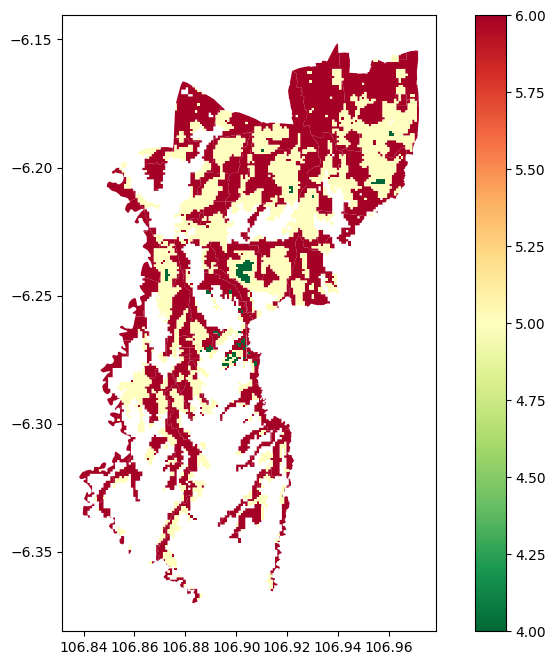

In [26]:
# Visualisasi Hasil

gdf_overlay.plot(
    column="TOTAL_SKOR",
    cmap="RdYlGn_r",  # merah tinggi → hijau rendah
    legend=True,
    figsize=(10, 8)
)


In [28]:
print(gdf_overlay.head(50))  


      fid ID_PROV_1   PROVINSI_1 ID_KABKOT_1                 KABKOT_1  \
0   20245        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
1   20245        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
2   20245        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
3   20245        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
4   20244        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
5   20244        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
6   20242        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
7   20242        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
8   20242        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
9   20242        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
10  20242        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
11  20242        31  DKI JAKARTA       31.75  KOTA ADM. JAKARTA TIMUR   
12  20242        31  DKI JAKARTA       31.75  KOTA 

In [29]:
# Tampilan Kolom Attribut

gdf_overlay[["KECAMATAN_1", "DESA_1", "SKOR_DEMOGRAFI", "SKOR_TUTUPAN", "SKOR_BANJIR", "TOTAL_SKOR", "KELAS_RISIKO"]].head(100)


,KECAMATAN_1,DESA_1,SKOR_DEMOGRAFI,SKOR_TUTUPAN,SKOR_BANJIR,TOTAL_SKOR,KELAS_RISIKO
0,MATRAMAN,UTAN KAYU UTARA,1,2.0,3,6.0,TINGGI
1,MATRAMAN,UTAN KAYU UTARA,1,2.0,2,5.0,SEDANG
2,MATRAMAN,UTAN KAYU UTARA,1,2.0,2,5.0,SEDANG
3,MATRAMAN,UTAN KAYU UTARA,1,2.0,2,5.0,SEDANG
4,MATRAMAN,UTAN KAYU SELATAN,1,2.0,3,6.0,TINGGI
...,...,...,...,...,...,...,...
95,CAKUNG,PULO GEBANG,1,2.0,1,4.0,RENDAH
96,CAKUNG,PULO GEBANG,1,2.0,3,6.0,TINGGI
97,CAKUNG,PULO GEBANG,1,2.0,2,5.0,SEDANG
98,CAKUNG,PULO GEBANG,1,2.0,3,6.0,TINGGI


In [30]:
# Urutkan dari risiko tertinggi (TOTAL_SKOR terbesar ke terkecil)
gdf_sorted = gdf_overlay.sort_values(by="TOTAL_SKOR", ascending=False)

# Tampilkan 10 baris teratas
print(gdf_sorted[["KECAMATAN_1", "DESA_1", "SKOR_DEMOGRAFI", "SKOR_TUTUPAN", "SKOR_BANJIR", "TOTAL_SKOR", "KELAS_RISIKO"]].head(50))


    KECAMATAN_1                  DESA_1  SKOR_DEMOGRAFI  SKOR_TUTUPAN  \
10       CAKUNG           UJUNG MENTENG               1           2.0   
12       CAKUNG           UJUNG MENTENG               1           2.0   
682  PASAR REBO                    BARU               1           2.0   
0      MATRAMAN         UTAN KAYU UTARA               1           2.0   
681  PASAR REBO                    BARU               1           2.0   
20   KRAMATJATI                  TENGAH               1           2.0   
16       CAKUNG           UJUNG MENTENG               1           2.0   
15       CAKUNG           UJUNG MENTENG               1           2.0   
14       CAKUNG           UJUNG MENTENG               1           2.0   
9        CAKUNG           UJUNG MENTENG               1           2.0   
604  PASAR REBO               CIJANTUNG               1           2.0   
633  KRAMATJATI                  CAWANG               1           2.0   
632  KRAMATJATI                  CAWANG            

In [31]:
# Export ke GeoJSON

output_path = "Kerentanan_Banjir_Jaktim.geojson"

# simpan ke file GeoJSON
gdf_overlay.to_file(output_path, driver="GeoJSON")

print(f"Hasil overlay berhasil diexport ke {output_path}")

Hasil overlay berhasil diexport ke Kerentanan_Banjir_Jaktim.geojson


In [32]:
import geopandas as gpd

# Baca file GeoJSON
gdf = gpd.read_file("Kerentanan_Banjir_Jaktim.geojson")

# Tampilkan sistem koordinat saat ini
print("CRS sebelum:", gdf.crs)

# Jika tidak terdefinisi (None), tetapkan EPSG asalnya dulu (ganti sesuai asal data kamu)
if gdf.crs is None:
    # Contoh: kalau dari QGIS UTM zona 48S (Jakarta), pakai EPSG:32748
    gdf.set_crs(epsg=32748, inplace=True)  # Ganti jika kamu tahu EPSG-nya berbeda

# Ubah ke WGS84 (EPSG:4326)
gdf_wgs84 = gdf.to_crs(epsg=4326)

# Simpan sebagai GeoJSON baru
gdf_wgs84.to_file("Kerentanan_Banjir_Jaktim_WGS84.geojson", driver="GeoJSON")

# Cek ulang
print("CRS sesudah:", gdf_wgs84.crs)
print("Berhasil disimpan sebagai Kerentanan_Banjir_Jaktim_WGS84.geojson")


CRS sebelum: EPSG:4326
CRS sesudah: EPSG:4326
Berhasil disimpan sebagai Kerentanan_Banjir_Jaktim_WGS84.geojson
